# Keyword analysis

In [1]:
import html

import polars as pl
import polars_corpus as plc
from polars._typing import IntoExprColumn, IntoExpr
from polars_corpus.utils import as_expr

In [2]:
bnc = pl.scan_parquet("bnc.parquet").set_sorted("file_id")
speakers = pl.scan_parquet("bnc-speakers.parquet")

speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

Stefanowitsch (2020), pp. 378–380

In [3]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ll',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

<Axes: >

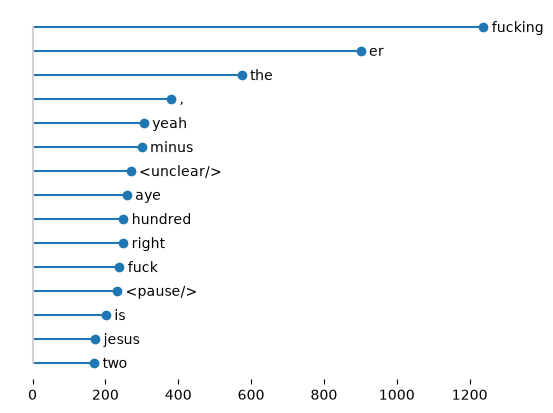

In [4]:
plc.keyword_plot(male_keywords, 'token', 'LogLik', top_k=15, descending=True)

In [5]:
tbl = (
    male_keywords.head(20)
    .select("token",
            pl.col('freqs').struct.field('f12').alias('male_freq'),
            (pl.col('freqs').struct.field('f1')-pl.col('freqs').struct.field('f12')).alias('female_freq'),
            'LogLik')
    .style.fmt_number(["LogLik"], decimals=2)
    .fmt_integer(["male_freq", "female_freq"], use_seps=True)
    .fmt(html.escape, columns=["token"])
    .cols_label(
        {
            "token": "word",
            "LogLik": "LL",
            "male_freq": "m freq",
            "female_freq": "f freq",
        }
    )
    .opt_row_striping()
    .opt_vertical_padding(0.6)
)

#tbl.save("LL")
tbl

word,m freq,f freq,LL
fucking,"1,383",326,"1,237.92"
er,"9,415","9,337",900.79
the,"43,385","57,367",574.38
",","84,406","119,150",380.47
yeah,"21,888","28,793",305.65
minus,257,35,299.75
<unclear/>,"30,659","41,710",269.42
aye,"1,164",876,258.85
hundred,"1,473","1,233",249.38
right,"6,081","7,092",249.24


In [11]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ll',
    min_target_tf=100,
    expr=plc.ngrams(4, 'token', as_str=True)
).filter(~pl.col('token').str.contains(r"[^A-Za-z' ]")).collect(engine="streaming")

<Axes: >

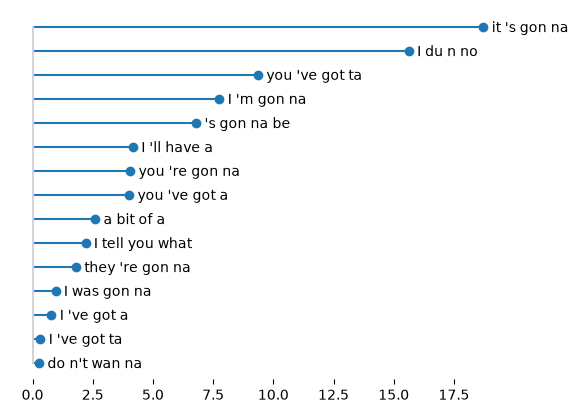

In [13]:
plc.keyword_plot(male_keywords, 'token', 'LogLik', top_k=15, descending=True)

<Axes: >

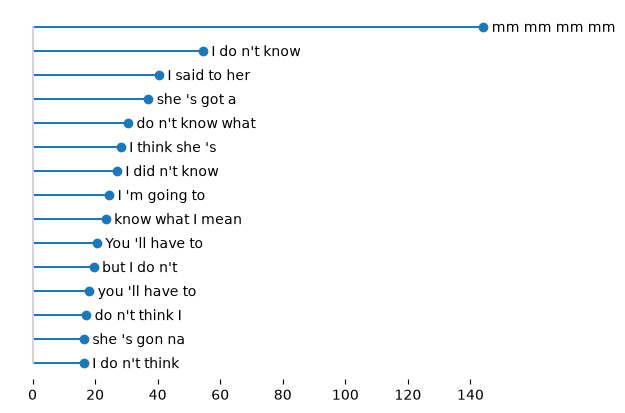

In [14]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f'),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ll',
    min_target_tf=100,
    expr=plc.ngrams(4, 'token', as_str=True)
).filter(~pl.col('token').str.contains(r"[^A-Za-z' ]")).collect(engine="streaming")

plc.keyword_plot(female_keywords, 'token', 'LogLik', top_k=15, descending=True)

Lijffijt et al. (2016)

In [15]:
male_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='m'),
    reference= bnc.filter(pl.col('sex')=='f'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

<Axes: >

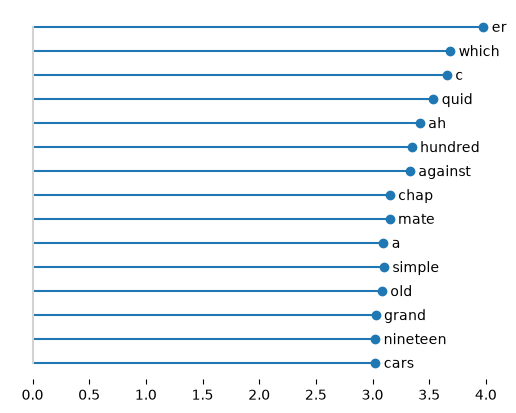

In [16]:
plc.keyword_plot(male_keywords, 'token', 'stat', top_k=15, descending=True)

In [17]:
female_keywords = plc.keywords(
    target = bnc.filter(pl.col('sex')=='f').lazy(),
    reference= bnc.filter(pl.col('sex')=='m'),
    method='ttest',
    expr=pl.col('token').str.to_lowercase()
).collect(engine="streaming")

<Axes: >

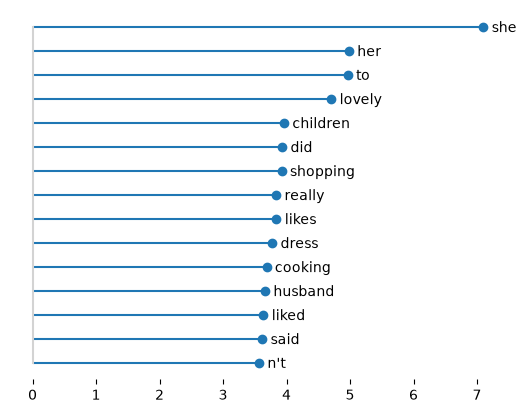

In [18]:
plc.keyword_plot(female_keywords, 'token', 'stat', top_k=15, descending=True)